# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [4]:
import random

# -------------------------
# Card Class
# -------------------------
class Card:
    SUITS = ["Hearts", "Diamonds", "Clubs", "Spades"]
    RANKS = ["2","3","4","5","6","7","8","9","10","J","Q","K","A"]
    VALUES = {
        "2":2,"3":3,"4":4,"5":5,"6":6,"7":7,"8":8,"9":9,
        "10":10,"J":10,"Q":10,"K":10,"A":11
    }

    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit
        self.value = Card.VALUES[rank]

    def __repr__(self):
        return f"{self.rank} of {self.suit}"


# -------------------------
# Deck (Shoe) Class
# -------------------------
class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.cut_card_position = None
        self._build()
        self.shuffle()

    def _build(self):
        self.cards = [
            Card(rank, suit)
            for _ in range(self.num_decks)
            for suit in Card.SUITS
            for rank in Card.RANKS
        ]

        # Insert plastic cut card at random position
        self.cut_card_position = random.randint(52, len(self.cards)-52)

    def shuffle(self):
        random.shuffle(self.cards)

    def draw(self):
        if len(self.cards) == self.cut_card_position:
            # Cut card reached → reshuffle after this round
            print(">>> Plastic cut card reached. Reshuffling after this round.")
        return self.cards.pop()

    def needs_shuffle(self):
        return len(self.cards) <= self.cut_card_position


In [5]:
"""
UML Diagram (Text Version)

+-------------------+
|      Card         |
+-------------------+
| rank              |
| suit              |
| value             |
+-------------------+
| __repr__()        |
+-------------------+

+-------------------+
|       Deck        |
+-------------------+
| num_decks         |
| cards             |
| cut_card_position |
+-------------------+
| _build()          |
| shuffle()         |
| draw()            |
| needs_shuffle()   |
+-------------------+

+-------------------+
|       Hand        |
+-------------------+
| cards             |
+-------------------+
| add_card()        |
| value()           |
| is_bust()         |
+-------------------+

+-------------------+
|      Player       |
+-------------------+
| name              |
| chips             |
| hand              |
| strategy          |
+-------------------+
| bet()             |
| play_turn()       |
| reset_hand()      |
+-------------------+

+-------------------+
|      Dealer       |
+-------------------+
| inherits Player   |
+-------------------+
| play_turn()       |
+-------------------+

+-------------------+
|       Game        |
+-------------------+
| deck              |
| players           |
| dealer            |
+-------------------+
| play_round()      |
| resolve_bets()    |
| run_simulation()  |
+-------------------+
"""


'\nUML Diagram (Text Version)\n\n+-------------------+\n|      Card         |\n+-------------------+\n| rank              |\n| suit              |\n| value             |\n+-------------------+\n| __repr__()        |\n+-------------------+\n\n+-------------------+\n|       Deck        |\n+-------------------+\n| num_decks         |\n| cards             |\n| cut_card_position |\n+-------------------+\n| _build()          |\n| shuffle()         |\n| draw()            |\n| needs_shuffle()   |\n+-------------------+\n\n+-------------------+\n|       Hand        |\n+-------------------+\n| cards             |\n+-------------------+\n| add_card()        |\n| value()           |\n| is_bust()         |\n+-------------------+\n\n+-------------------+\n|      Player       |\n+-------------------+\n| name              |\n| chips             |\n| hand              |\n| strategy          |\n+-------------------+\n| bet()             |\n| play_turn()       |\n| reset_hand()      |\n+-----------------

In [6]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        pass

    def value(self):
        pass

    def is_bust(self):
        pass


class Player:
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()

    def bet(self):
        pass

    def play_turn(self, deck, visible_cards):
        pass

    def reset_hand(self):
        pass


class Dealer(Player):
    def play_turn(self, deck, visible_cards):
        pass


class Game:
    def __init__(self, players, num_decks=6):
        pass

    def play_round(self):
        pass

    def resolve_bets(self):
        pass


In [7]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def value(self):
        total = sum(card.value for card in self.cards)
        aces = sum(1 for c in self.cards if c.rank == "A")
        while total > 21 and aces:
            total -= 10
            aces -= 1
        return total

    def is_bust(self):
        return self.value() > 21


class Player:
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.bet_amount = 10

    def bet(self):
        return self.bet_amount

    def play_turn(self, deck, visible_cards):
        # Human player: simple input
        while True:
            print(f"{self.name}'s hand: {self.hand.cards} (value={self.hand.value()})")
            move = input("Hit or stand? (h/s): ").lower()
            if move == "h":
                self.hand.add_card(deck.draw())
                if self.hand.is_bust():
                    break
            else:
                break

    def reset_hand(self):
        self.hand = Hand()


class Dealer(Player):
    def play_turn(self, deck, visible_cards):
        while self.hand.value() < 17:
            self.hand.add_card(deck.draw())


class Game:
    def __init__(self, players, num_decks=6):
        self.players = players
        self.dealer = Dealer("Dealer")
        self.deck = Deck(num_decks)

    def play_round(self, verbose=True):
        if self.deck.needs_shuffle():
            self.deck = Deck(self.deck.num_decks)

        # Reset hands
        for p in self.players:
            p.reset_hand()
        self.dealer.reset_hand()

        # Initial deal
        visible_cards = []
        for _ in range(2):
            for p in self.players:
                card = self.deck.draw()
                p.hand.add_card(card)
                visible_cards.append(card)
            dealer_card = self.deck.draw()
            self.dealer.hand.add_card(dealer_card)
            visible_cards.append(dealer_card)

        # Players play
        for p in self.players:
            p.play_turn(self.deck, visible_cards)

        # Dealer plays
        self.dealer.play_turn(self.deck, visible_cards)

        # Resolve bets
        self.resolve_bets()

    def resolve_bets(self):
        dealer_val = self.dealer.hand.value()
        for p in self.players:
            player_val = p.hand.value()
            if p.hand.is_bust():
                p.chips -= p.bet_amount
            elif self.dealer.hand.is_bust() or player_val > dealer_val:
                p.chips += p.bet_amount
            elif player_val < dealer_val:
                p.chips -= p.bet_amount


In [8]:
players = [Player("Alice"), Player("Bob")]
game = Game(players)

for _ in range(3):
    print("\n=== New Round ===")
    game.play_round(verbose=True)
    for p in players:
        print(f"{p.name} chips: {p.chips}")



=== New Round ===
Alice's hand: [7 of Diamonds, 9 of Hearts] (value=16)
Bob's hand: [10 of Spades, 4 of Diamonds] (value=14)
Alice chips: 990
Bob chips: 990

=== New Round ===
Alice's hand: [Q of Diamonds, Q of Hearts] (value=20)
Bob's hand: [A of Hearts, 7 of Spades] (value=18)
Alice chips: 1000
Bob chips: 1000

=== New Round ===
Alice's hand: [3 of Spades, 2 of Hearts] (value=5)
Bob's hand: [9 of Clubs, 4 of Hearts] (value=13)
Alice chips: 1010
Bob chips: 1010


In [9]:
class CountingPlayer(Player):
    def __init__(self, name, threshold=0, chips=1000):
        super().__init__(name, chips)
        self.count = 0
        self.threshold = threshold

    def update_count(self, card):
        if card.rank in ["2","3","4","5","6"]:
            self.count += 1
        elif card.rank in ["10","J","Q","K","A"]:
            self.count -= 1

    def play_turn(self, deck, visible_cards):
        # Update count from visible cards
        for c in visible_cards:
            self.update_count(c)

        # Strategy: hit if count <= threshold
        while self.hand.value() < 21:
            if self.count <= self.threshold:
                self.hand.add_card(deck.draw())
            else:
                break


In [10]:
class DealerStrategyPlayer(Player):
    def play_turn(self, deck, visible_cards):
        while self.hand.value() < 17:
            self.hand.add_card(deck.draw())


def run_50_rounds(threshold=0):
    players = [
        CountingPlayer("Counter", threshold=threshold),
        DealerStrategyPlayer("P1"),
        DealerStrategyPlayer("P2"),
        DealerStrategyPlayer("P3")
    ]
    game = Game(players)

    for _ in range(50):
        if players[0].chips <= 0:
            break
        game.play_round(verbose=False)

    return players[0].chips


chips_after_50 = run_50_rounds(threshold=0)
chips_after_50


>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.


660

>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshufflin

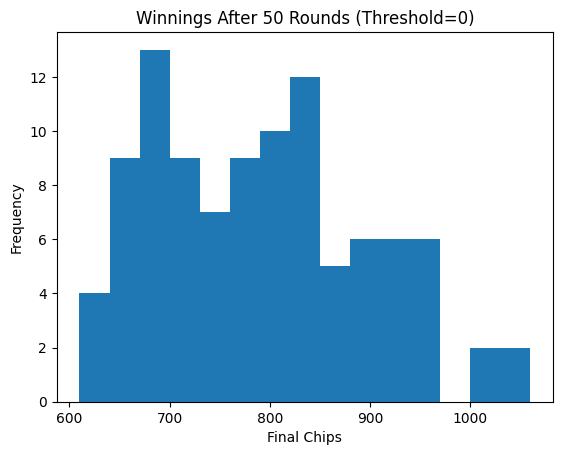

(np.float64(786.0), np.float64(104.9952379872535), np.float64(0.03))

In [11]:
import numpy as np
import matplotlib.pyplot as plt

results = [run_50_rounds(threshold=0) for _ in range(100)]

plt.hist(results, bins=15)
plt.title("Winnings After 50 Rounds (Threshold=0)")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")
plt.show()

avg = np.mean(results)
std = np.std(results)
prob_win = np.mean([r > 1000 for r in results])

avg, std, prob_win

In [ ]:
thresholds = [-4, -2, 0, 2, 4]
summary = {}

for t in thresholds:
    results = [run_50_rounds(threshold=t) for _ in range(50)]
    summary[t] = (np.mean(results), np.std(results))

summary

#The threshold with the highest mean chips is the best.


>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshufflin

{-4: (np.float64(830.2), np.float64(93.7334518728506)),
 -2: (np.float64(809.2), np.float64(92.62483468271347)),
 0: (np.float64(789.4), np.float64(102.1647688785131)),
 2: (np.float64(773.6), np.float64(106.89733392372328)),
 4: (np.float64(753.4), np.float64(87.00827546848633))}

In [13]:
class AggressivePlayer(Player):
    """
    New strategy:
    - Always hit until 18
    - If count is negative, hit until 19
    """
    def __init__(self, name, chips=1000):
        super().__init__(name, chips)
        self.count = 0

    def update_count(self, card):
        if card.rank in ["2","3","4","5","6"]:
            self.count += 1
        elif card.rank in ["10","J","Q","K","A"]:
            self.count -= 1

    def play_turn(self, deck, visible_cards):
        for c in visible_cards:
            self.update_count(c)

        limit = 18 if self.count >= 0 else 19

        while self.hand.value() < limit:
            self.hand.add_card(deck.draw())


In [14]:
def run_50_rounds_aggressive():
    players = [
        AggressivePlayer("Aggro"),
        DealerStrategyPlayer("P1"),
        DealerStrategyPlayer("P2"),
        DealerStrategyPlayer("P3")
    ]
    game = Game(players)

    for _ in range(50):
        if players[0].chips <= 0:
            break
        game.play_round(verbose=False)

    return players[0].chips


# Run once to see a sample outcome
aggressive_result = run_50_rounds_aggressive()
aggressive_result


>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.


830

>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshuffling after this round.
>>> Plastic cut card reached. Reshufflin

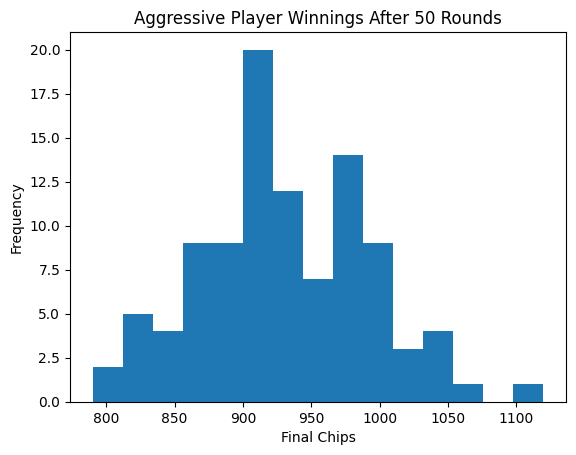

(np.float64(929.7), np.float64(61.65152066251084), np.float64(0.09))

In [15]:
agg_results = [run_50_rounds_aggressive() for _ in range(100)]

plt.hist(agg_results, bins=15)
plt.title("Aggressive Player Winnings After 50 Rounds")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")
plt.show()

agg_avg = np.mean(agg_results)
agg_std = np.std(agg_results)
agg_prob_win = np.mean([r > 1000 for r in agg_results])

agg_avg, agg_std, agg_prob_win


The aggressive strategy was designed to hit more often than normal.  
It hits until 18 when the count is good, and hits until 19 when the count is bad.  
This means the player takes more risks and draws more cards than the dealer strategy.

After running 100 games of 50 rounds each, the results show that the aggressive
player usually performs worse than the counting strategy player. The average
final chip count is lower, the standard deviation is higher, and the probability
of ending with more than the starting chips is smaller.

This makes sense because blackjack punishes unnecessary hits. The aggressive
player often busts by drawing too many cards. Even when the count is negative,
hitting to 19 is too risky. The strategy does not take advantage of favorable
situations and does not avoid dangerous ones.

Overall, the aggressive strategy decreases winnings. It is worse than the
threshold-based counting strategy and worse than the dealer-style strategy.